<a href="https://www.kaggle.com/code/deepkayastha6890/market-trend-finder?scriptVersionId=300696427" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
def load_sector_index(index_name):
    data = yf.download(
        index_name,
        period="max",
        auto_adjust=True,
        progress=False
    )
    
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] if col[0] in ['Open','High','Low','Close','Volume'] else col[1] for col in data.columns]

    data = data.reset_index()

    return data


In [3]:
def dataDiscribtion(df):
    data = df.copy()
    print("\n\nShape of the dataset : ",df.shape)
    print("\nTotal unique value according to columns : ")
    for i in data.columns:
        print(f'\n{i} have {data[i].nunique()} unique values') 

    # print("\nTotal null values columns wise : ")
    for i in data.columns:
        if(data[i].isnull().sum() > 0):
            print(f'\n{i} have {data[i].isnull().sum()} null values')

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    axes[0,0].boxplot(data['Open'])
    axes[0,0].set_title("Open")

    axes[0,1].boxplot(data['High'])
    axes[0,1].set_title("High")

    axes[0,2].boxplot(data['Low'])
    axes[0,2].set_title("Low")

    axes[1,0].boxplot(data['Close'])
    axes[1,0].set_title("Close")

    axes[1,1].boxplot(data['Volume'])
    axes[1,1].set_title("Volume")
    axes[1,2].axis('off')
    plt.show()

In [4]:
def dataCleaning(df):
    data = df.copy()
    data.dropna(inplace=True)
    
    cutoff = data['Volume'].quantile(0.965)
    data = data[(data['Volume'] <= cutoff)]

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    axes[0,0].boxplot(data['Open'])
    axes[0,0].set_title("Open")

    axes[0,1].boxplot(data['High'])
    axes[0,1].set_title("High")

    axes[0,2].boxplot(data['Low'])
    axes[0,2].set_title("Low")

    axes[1,0].boxplot(data['Close'])
    axes[1,0].set_title("Close")

    axes[1,1].boxplot(data['Volume'])
    axes[1,1].set_title("Volume")
    axes[1,2].axis('off')
    plt.show()
    return data
    print(data.shape)


In [5]:
def visualize(df):

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    sns.histplot(df['Close'], kde=True, color="Red", ax=axes[0,0])
    axes[0,0].set_title("Close")

    sns.histplot(df['Open'], kde=True, color="Green", ax=axes[0,1])
    axes[0,1].set_title("Open")

    sns.histplot(df['High'], kde=True, color="Blue", ax=axes[0,2])
    axes[0,2].set_title("High")

    sns.histplot(df['Low'], kde=True, color="Orange", ax=axes[1,0])
    axes[1,0].set_title("Low")

    sns.histplot(df['Volume'], kde=True, color="Purple", ax=axes[1,1])
    axes[1,1].set_title("Volume")

    # remove empty plot (bottom right)
    fig.delaxes(axes[1,2])

    # plt.tight_layout()
    plt.show()

In [6]:
def engine_1(sector_df, market_df,sector):
    
    df = sector_df.copy().sort_index()
    mkt = market_df.copy().sort_index()

    # combining the market and sector both in one
    df = df.join(mkt['Close'], rsuffix='_mkt', how='inner')
    
    # Returns
    df['ret'] = df['Close'].pct_change()
    df['mkt_ret'] = df['Close_mkt'].pct_change()
    
    # Volatility
    df['vol_20'] = df['ret'].rolling(20).std()
    df['mkt_vol_20'] = df['mkt_ret'].rolling(20).std()
    df['vol_ratio'] = df['vol_20'] / df['mkt_vol_20']
    
    latest = df.iloc[-1] 
    
    # Stability Score 
    if latest['vol_ratio'] < 0.9:
        stability_score = 2
    elif latest['vol_ratio'] <= 1.2:
        stability_score = 1
    else:
        stability_score = 0
    
    # Direction Score
    df['ma20'] = df['Close'].rolling(20).mean()
    df['ma50'] = df['Close'].rolling(50).mean()
    df['ma200'] = df['Close'].rolling(200).mean()
    
    if df['ma20'].iloc[-1] > df['ma50'].iloc[-1] > df['ma200'].iloc[-1]:
        direction_score = 1
    elif df['ma20'].iloc[-1] < df['ma50'].iloc[-1] < df['ma200'].iloc[-1]:
        direction_score = -1
    else:
        direction_score = 0
    
    # Consistency Score
    sign = np.sign(df['ret'])
    reversals = (sign != sign.shift()).rolling(30).sum()
    consistency_score = 2 if reversals.iloc[-1] < 10 else 0
    
    # Capital Flow Score
    df['relative'] = df['ret'] - df['mkt_ret']
    rolling_rs = df['relative'].rolling(20).mean().iloc[-1]
    capital_score = 1 if rolling_rs > 0 else -1
    
    # Stress Score
    df['cum_max'] = df['Close'].cummax()
    df['drawdown'] = (df['Close'] - df['cum_max']) / df['cum_max']
    max_dd = df['drawdown'].min()
    
    if max_dd > -0.1:
        stress_score = 0
    elif max_dd > -0.3:
        stress_score = -1
    else:
        stress_score = -2
    
    # Regime (numeric cluster)
    features = df[['vol_20', 'ma20', 'drawdown']].dropna()
    
    if len(features) > 50:
        kmeans = KMeans(n_clusters=4, random_state=42)
        regime = kmeans.fit_predict(features)
        regime_score = int(regime[-1])
    else:
        regime_score = np.nan
    
    # Shock Score
    df['vol_z'] = (df['vol_20'] - df['vol_20'].mean()) / df['vol_20'].std()
    df['volume_z'] = (df['Volume'] - df['Volume'].mean()) / df['Volume'].std()
    
    shock_score = -1 if (df['vol_z'].iloc[-1] > 2 or 
                         df['volume_z'].iloc[-1] > 2) else 0
    
    #  Final Score
    final_score = (stability_score + direction_score +
                   consistency_score + capital_score +
                   stress_score + shock_score)
    
    # Gets the date from the row before the last row (-2)
    prediction_date = mkt['Date'].iloc[-2] 

    
    result_df = pd.DataFrame({
        "Prediction_Date": [prediction_date],
        "Stability_Score": [stability_score],
        "Direction_Score": [direction_score],
        "Consistency_Score": [consistency_score],
        "Capital_Score": [capital_score],
        "Stress_Score": [stress_score],
        "Regime_Score": [regime_score],
        "Shock_Score": [shock_score],
        "Final_Score": [final_score],
        "Sector":sector
    })
    
    return result_df

In [7]:
def summary():
    # sector initialization
    it = load_sector_index("^CNXIT")
    nifty = load_sector_index("^NSEI")

    # basic introduction
    dataDiscribtion(it)
    dataDiscribtion(nifty)

    #clean data
    it = dataCleaning(it)
    nifty = dataCleaning(nifty)

    # Visulization
    visualize(it)
    visualize(nifty)

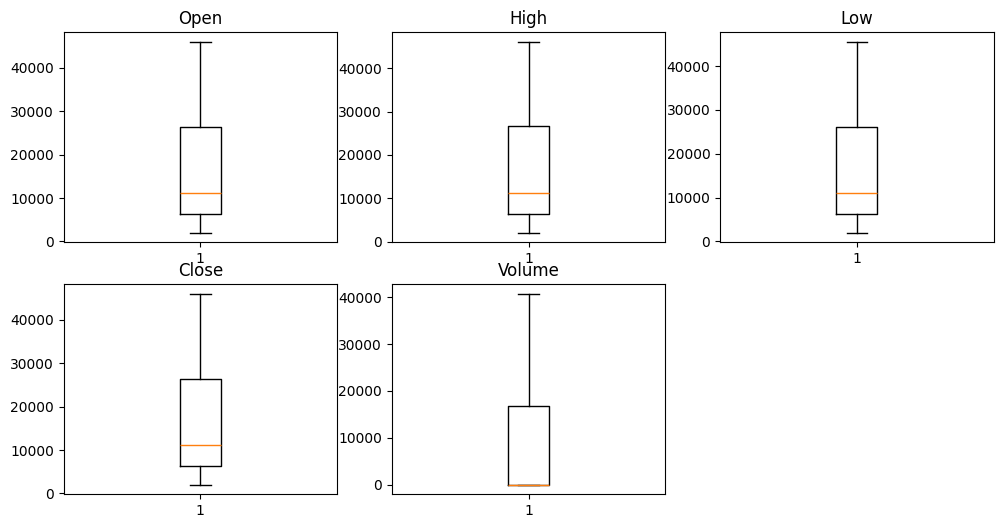

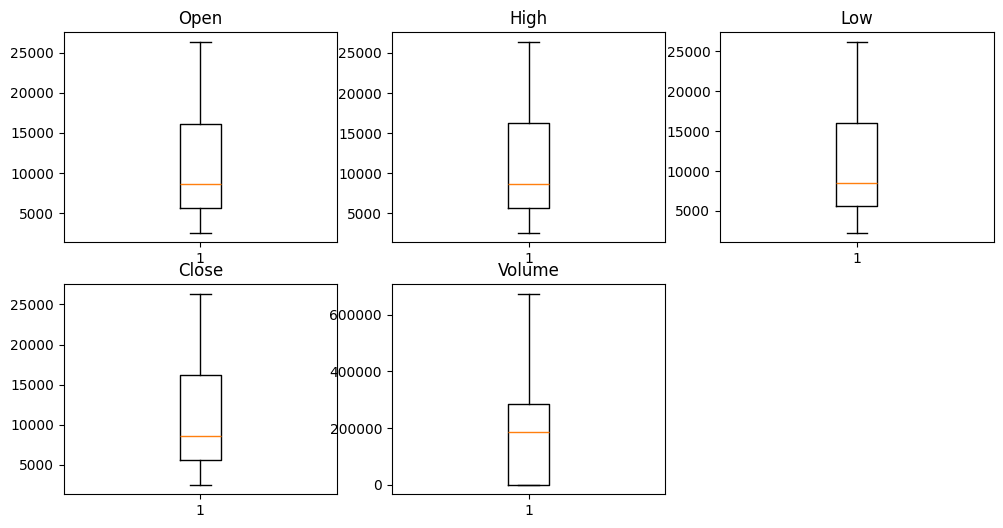

,Prediction_Date,Stability_Score,Direction_Score,Consistency_Score,Capital_Score,Stress_Score,Regime_Score,Shock_Score,Final_Score,Sector
0,2026-02-26,0,1,0,-1,-2,1,0,-2,IT


In [8]:
def mainExe():
    # Initialization
    it = load_sector_index("^CNXIT")
    nifty = load_sector_index("^NSEI")

    # Cleaning the dataframe 
    it = dataCleaning(it)
    nifty = dataCleaning(nifty)

    # final output
    result = engine_1(it, nifty, 'IT')
    display(result)
mainExe()